In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("apple_supplier_dataset_10000.csv")
df.head()

,Supplier_ID,Supplier_Name,Country,Region,Product_Category,Manufacturing_Type,Supply_Volume,Defect_Rate,Lead_Time_Days,Cost_per_Unit,Risk_Score,Sustainability_Score,Quarter,Year
0,S00001,Texas Instruments,Vietnam,APAC,Apple Watch,Display,16795,4.76,47,392.05,21,88,Q4,2026
1,S00002,Jabil,Vietnam,APAC,iPad,Battery,7265,0.86,15,235.03,100,89,Q4,2026
2,S00003,Corning,Malaysia,APAC,MacBook,Logistics,17023,3.29,57,485.26,30,87,Q4,2025
3,S00004,Wistron,Malaysia,APAC,Apple Watch,Semiconductor,3433,0.99,25,312.57,58,71,Q3,2025
4,S00005,Broadcom,Japan,APAC,iPad,Camera,7396,2.22,53,267.14,42,77,Q3,2023


In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Supplier_ID           10000 non-null  object 
 1   Supplier_Name         10000 non-null  object 
 2   Country               10000 non-null  object 
 3   Region                10000 non-null  object 
 4   Product_Category      10000 non-null  object 
 5   Manufacturing_Type    10000 non-null  object 
 6   Supply_Volume         10000 non-null  int64  
 7   Defect_Rate           10000 non-null  float64
 8   Lead_Time_Days        10000 non-null  int64  
 9   Cost_per_Unit         10000 non-null  float64
 10  Risk_Score            10000 non-null  int64  
 11  Sustainability_Score  10000 non-null  int64  
 12  Quarter               10000 non-null  object 
 13  Year                  10000 non-null  int64  
dtypes: float64(2), int64(5), object(7)
memory usage: 1.1+ MB


,Supply_Volume,Defect_Rate,Lead_Time_Days,Cost_per_Unit,Risk_Score,Sustainability_Score,Year
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25279.341100,2.578084,32.139400,254.521117,50.352600,74.598600,2024.515000
std,14138.105898,1.423052,15.991927,140.981308,28.857137,14.348452,1.116647
min,1005.000000,0.100000,5.000000,10.020000,1.000000,50.000000,2023.000000
25%,13030.500000,1.340000,18.000000,132.240000,25.000000,62.000000,2024.000000
50%,24977.000000,2.600000,32.000000,253.835000,50.000000,75.000000,2025.000000
75%,37515.000000,3.830000,46.000000,375.862500,75.000000,87.000000,2026.000000
max,49988.000000,5.000000,59.000000,499.950000,100.000000,99.000000,2026.000000


In [8]:
df.isnull().sum()

,0
Supplier_ID,0
Supplier_Name,0
Country,0
Region,0
Product_Category,0
Manufacturing_Type,0
Supply_Volume,0
Defect_Rate,0
Lead_Time_Days,0
Cost_per_Unit,0


In [9]:
df.duplicated().sum()


np.int64(0)

In [10]:
df.dtypes

,0
Supplier_ID,object
Supplier_Name,object
Country,object
Region,object
Product_Category,object
Manufacturing_Type,object
Supply_Volume,int64
Defect_Rate,float64
Lead_Time_Days,int64
Cost_per_Unit,float64


In [11]:
df['Supplier_Name'].nunique()

20

In [12]:
df['Lead_Time_Days'].mean()

np.float64(32.1394)

In [13]:
df['Defect_Rate'].mean()

np.float64(2.5780839999999996)

In [14]:
  df['Risk_Score'].mean()

np.float64(50.3526)

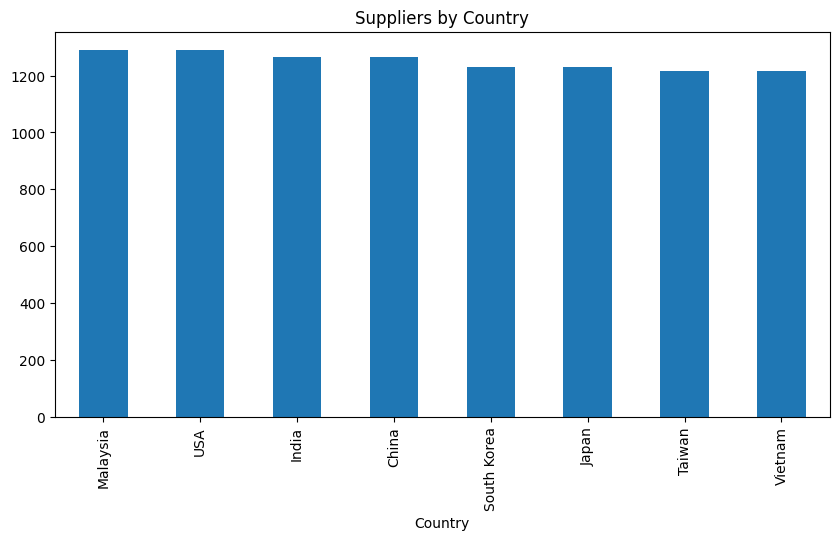

In [15]:
df['Country'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Suppliers by Country")
plt.show()

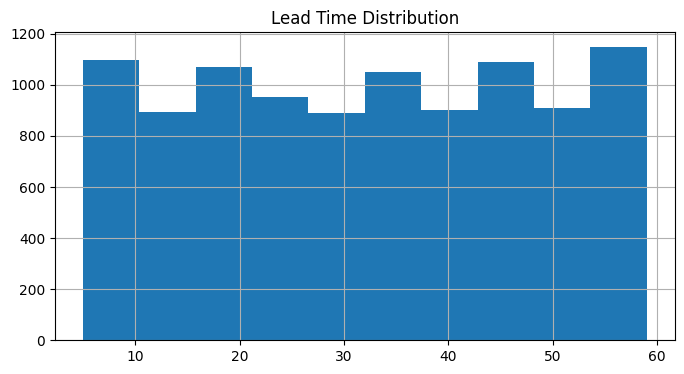

In [16]:
df['Lead_Time_Days'].hist(figsize=(8,4))
plt.title("Lead Time Distribution")
plt.show()

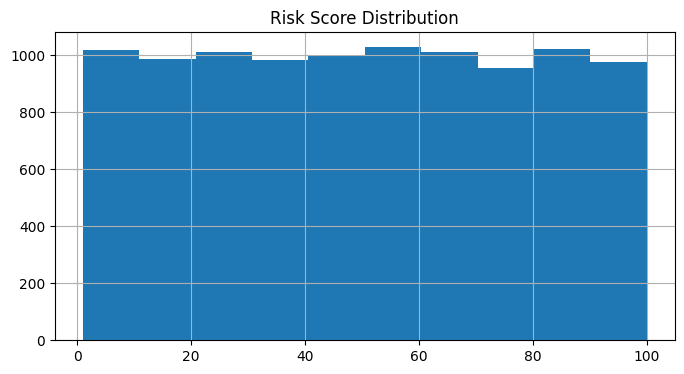

In [17]:
df['Risk_Score'].hist(figsize=(8,4))
plt.title("Risk Score Distribution")
plt.show()

In [18]:
df.groupby('Country')['Supply_Volume'].sum().sort_values(ascending=False)

,Supply_Volume
Country,
Malaysia,33905528
China,32570569
India,31952574
USA,31638982
South Korea,31114018
Taiwan,30912815
Japan,30733042
Vietnam,29965883


In [19]:
df['Risk_Category'] = df['Risk_Score'].apply(
    lambda x: 'Low' if x <= 35 else ('Medium' if x <= 70 else 'High')
)

In [20]:
df.head()

,Supplier_ID,Supplier_Name,Country,Region,Product_Category,Manufacturing_Type,Supply_Volume,Defect_Rate,Lead_Time_Days,Cost_per_Unit,Risk_Score,Sustainability_Score,Quarter,Year,Risk_Category
0,S00001,Texas Instruments,Vietnam,APAC,Apple Watch,Display,16795,4.76,47,392.05,21,88,Q4,2026,Low
1,S00002,Jabil,Vietnam,APAC,iPad,Battery,7265,0.86,15,235.03,100,89,Q4,2026,High
2,S00003,Corning,Malaysia,APAC,MacBook,Logistics,17023,3.29,57,485.26,30,87,Q4,2025,Low
3,S00004,Wistron,Malaysia,APAC,Apple Watch,Semiconductor,3433,0.99,25,312.57,58,71,Q3,2025,Medium
4,S00005,Broadcom,Japan,APAC,iPad,Camera,7396,2.22,53,267.14,42,77,Q3,2023,Medium


In [21]:
df.to_csv("apple_supplier_cleaned.csv", index=False)